In [3]:
import numpy as np
import pandas as pd
import sys
from scipy.stats import sem
import matplotlib.pyplot as plt
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P'])
from rois.rois import remove_bad_cells
import seaborn as sb
#plt.style.use(['/Users/amonast/Documents/GitHub/Amy_Reviews/notebooks/paper_style.mplstyle'])

In [5]:
base_dir = '/Volumes/AM_SSD1/Spont2P'
file_key = '/Volumes/AM_SSD1/Spont2P/Data_info.csv'
animals = ['589L',
            '989N',
            '992N',
            '992L',
            '994R',
            '9972R',
            '217R',
            '217N',
            '218L',
            '034R',
            '149L',
            '146R',
            '160R',
            '492N',
            '493R',
            '1912L']
fov_lists = [['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV2'],
            ['FOV2'],
            ['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV1'],
            ['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV1'],
            ['FOV1','FOV2'],
            ['FOV2'],
            ['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV1'],
            ['FOV1','FOV2']]

In [6]:
info=pd.read_csv(file_key)
fc=[]
hc=[]
for ani in animals:
    group = info.loc[info['Animal'] == ani, 'Group'].values
    if len(group) > 0:
        if group[0] == 'HC':
            hc.append(ani)
        elif group[0] == 'FC':
            fc.append(ani)
print(str(len(fc))+' fc animals')
print(str(len(hc))+' hc animals')

8 fc animals
8 hc animals


# #Cells per FOV

In [17]:
N_D0_all = []
N_D4_all = []
N_reg = []
n_cell_df = []
for a,ani in enumerate(animals):
    group=info['Group'].loc[info['Animal']==ani].values[0]
    fovs = fov_lists[a]
    for fov in fovs:
        df = remove_bad_cells(ani,fov,file_key,base_dir,snr_thr=4.0,filter_mchleak=True,return_leaky=False)
        n_D0_tot = df.loc[df.Baseline!=-1].shape[0]
        n_D4_tot = df.loc[df.Post!=-1].shape[0]
        n_reg = df.loc[(df.Baseline!=-1)&(df.Post!=-1)].shape[0]
        N_D0_all.append(n_D0_tot)
        N_D4_all.append(n_D4_tot)
        N_reg.append(n_reg)
        
        n_cell_df.append(pd.DataFrame({'Animal':ani,'FOV':fov,'Group':group,'N_cells':N_D0_all,'Session':'D0'}))
        n_cell_df.append(pd.DataFrame({'Animal':ani,'FOV':fov,'Group':group,'N_cells':N_D4_all,'Session':'D4'}))



/Volumes/AM_SSD1/Spont2P/Tagging/589L_FOV1_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/589L_FOV1/cellRegistered_20220111_145423.mat
356 Cells detected in registration
245 Cells detected in session 1 of 2
259 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
dropped leaky cell
dropped leaky cell
356 cells filtered to 256cells
/Volumes/AM_SSD1/Spont2P/Tagging/589L_FOV2_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/589L_FOV2/cellRegistered_20220111_145726.mat
326 Cells detected in registration
218 Cells detected in session 1 of 2
216 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
326 cells filtered to 157cells
/Volumes/AM_SSD1/Spont2P/Tagging/989N_FOV1_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/989N_FOV1/cellRegistered_20220613_225153.mat
378 Cells detected in registration
260 Cells detected in session 1 of 2
253 Cells detected in session 2 o

In [18]:
all = [i for listi in [N_D0_all,N_D4_all] for i in listi]

In [19]:
print(str(np.mean(all)) + '  +/-  '+ str(sem(all)) +'cells per fov')

176.84615384615384  +/-  5.975464200360699cells per fov


In [20]:
all_df = pd.concat(n_cell_df)

In [23]:
all_df

,Animal,FOV,Group,N_cells,Session
0,589L,FOV1,HC,190,D0
0,589L,FOV1,HC,194,D4
0,589L,FOV2,HC,190,D0
1,589L,FOV2,HC,115,D0
0,589L,FOV2,HC,194,D4
...,...,...,...,...,...
21,1912L,FOV2,HC,163,D4
22,1912L,FOV2,HC,177,D4
23,1912L,FOV2,HC,65,D4
24,1912L,FOV2,HC,119,D4


Text(0, 0.5, '# Recorded Cells / FOV')

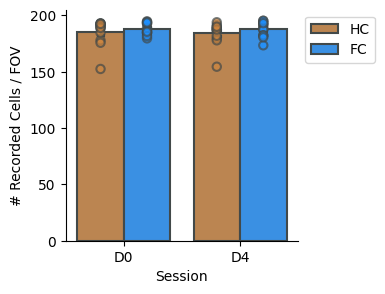

In [29]:
ani_mean = all_df.groupby(['Animal','Session','FOV','Group']).mean('N_cells').reset_index()
gray='#424949'
colors_group = ['peru','dodgerblue']
fig,ax=plt.subplots(figsize=(3,3))
sb.stripplot(data=ani_mean,x='Session',hue='Group',y='N_cells',palette=colors_group,
             edgecolor=gray, linewidth=1.5, dodge=True,jitter=0, alpha=.7, size=6,legend=False,ax=ax)
sb.barplot(data=ani_mean,x='Session',hue='Group',y='N_cells',errorbar='se',
                palette=colors_group,ax=ax,capsize=.1,linewidth=1.5,edgecolor=gray,err_kws={'color':gray})
sb.despine()
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('# Recorded Cells / FOV')

# Proportion of cells that Turnover

In [23]:
percent_reg = []
percent_drop = []
percent_new = []
for a,ani in enumerate(animals):
    fovs = fov_lists[a]
    for fov in fovs:
        df = remove_bad_cells(ani,fov,file_key,base_dir,snr_thr=4.0,filter_mchleak=True,return_leaky=False)
        n_D0_tot = df.loc[df.Baseline!=-1].shape[0]
        n_D4_tot = df.loc[df.Post!=-1].shape[0]
        n_reg = df.loc[(df.Baseline!=-1)&(df.Post!=-1)].shape[0]
        D4_new = df.loc[(df.Baseline==-1)&(df.Post!=-1)].shape[0]
        D0_drop = df.loc[(df.Baseline!=-1)&(df.Post==-1)].shape[0]
        percent_reg.append(n_reg/n_D0_tot*100)
        percent_new.append(D4_new/n_D4_tot*100)
        percent_drop.append(D0_drop/n_D0_tot*100)


/Volumes/AM_SSD1/Spont2P/Tagging/589L_FOV1_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/589L_FOV1/cellRegistered_20220111_145423.mat
356 Cells detected in registration
245 Cells detected in session 1 of 2
259 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
dropped leaky cell
dropped leaky cell
356 cells filtered to 256cells
128 registered cells
62 baseline only cells
66 post only cells
/Volumes/AM_SSD1/Spont2P/Tagging/589L_FOV2_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/589L_FOV2/cellRegistered_20220111_145726.mat
326 Cells detected in registration
218 Cells detected in session 1 of 2
216 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
326 cells filtered to 157cells
73 registered cells
42 baseline only cells
42 post only cells
/Volumes/AM_SSD1/Spont2P/Tagging/989N_FOV1_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/989N_FOV1/cellRegistered_

In [24]:
print(str(np.mean(percent_reg)) + '  +/-  '+ str(sem(percent_reg)) +' cells registered')

54.96423805925115  +/-  1.6718181574285889 cells registered


In [25]:
print(str(np.mean(percent_drop)) + '  +/-  '+ str(sem(percent_drop)) +' cells on D4 come online')

45.03576194074885  +/-  1.6718181574285886 cells on D4 come online


# False positive registered cell pairs

In [9]:
from rois.rois import get_fov_data
fp_all = []
for a,ani in enumerate(animals):
    fovs = fov_lists[a]
    for fov in fovs:
        cellreg = get_fov_data(ani, fov, file_key, base_dir)[0]
        filt_df = remove_bad_cells(ani,fov,file_key,base_dir,snr_thr=1.0,filter_mchleak=True,return_leaky=False)
        n_reg = filt_df.loc[(filt_df.Baseline!=-1)&(filt_df.Post!=-1)].shape[0]
        n_reg_og = cellreg[np.logical_and(cellreg[:,0]!=-1,cellreg[:,1]!=-1),:].shape[0]
        fp =(n_reg_og-n_reg)/n_reg_og*100
        fp_all.append(fp)


Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/589L_FOV1/cellRegistered_20220111_145423.mat
356 Cells detected in registration
245 Cells detected in session 1 of 2
259 Cells detected in session 2 of 2
/Volumes/AM_SSD1/Spont2P/Tagging/589L_FOV1_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/589L_FOV1/cellRegistered_20220111_145423.mat
356 Cells detected in registration
245 Cells detected in session 1 of 2
259 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
dropped leaky cell
dropped leaky cell
356 cells filtered to 264cells
130 registered cells
64 baseline only cells
70 post only cells
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/589L_FOV2/cellRegistered_20220111_145726.mat
326 Cells detected in registration
218 Cells detected in session 1 of 2
216 Cells detected in session 2 of 2
/Volumes/AM_SSD1/Spont2P/Tagging/589L_FOV2_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/58

In [10]:
info=pd.read_csv(file_key)
DF = pd.DataFrame()
for a,ani in enumerate(animals):
    fovs = fov_lists[a]
    for fov in fovs:
        group=info.Group.loc[info.Animal==ani].values[0]
        fov=info.FOV.loc[info.FOV==fov].values[0]
        df = pd.DataFrame({'Animal':[ani],'Group':[group],'FOV':[fov]})
        DF= pd.concat([DF,df],ignore_index=True)
DF['% FP']=fp_all
DF = DF.reset_index()

In [11]:
DF['AnimalLabel']=DF['Animal'].map({'9972R':'FC1','992N':'FC2','989N':'FC3',
           '149L':'FC4','146R':'FC5','160R':'FC6','492N':'FC7','493R':'FC8',
           '589L':'HC1','992L':'HC2','994R':'HC3',
           '034R':'HC4','217N':'HC5','218L':'HC6','217R':'HC7','1912L':'HC8'})

In [12]:
DF=DF.sort_values('AnimalLabel')

# Supp Fig2C - False positives out of Registered Cells

In [13]:
DF

,index,Animal,Group,FOV,% FP,AnimalLabel
9,9,9972R,FC,FOV2,13.333333,FC1
8,8,9972R,FC,FOV1,10.101010,FC1
4,4,992N,FC,FOV2,7.758621,FC2
2,2,989N,FC,FOV1,2.962963,FC3
3,3,989N,FC,FOV2,18.400000,FC3
16,16,149L,FC,FOV1,25.174825,FC4
17,17,149L,FC,FOV2,15.862069,FC4
18,18,146R,FC,FOV2,42.774566,FC5
20,20,160R,FC,FOV2,14.018692,FC6
19,19,160R,FC,FOV1,3.333333,FC6


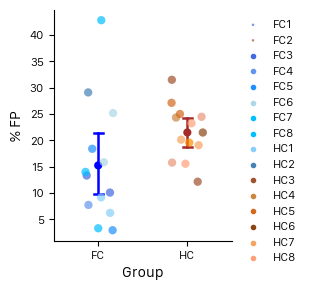

In [26]:
colors={'FC1':'royalblue','FC2':'cornflowerblue','FC3':'dodgerblue','FC4':'#ADD8E6','FC5':'#00BFFF','FC6':'deepskyblue','FC7':'lightskyblue','FC8':'steelblue',	
        'HC1':'sienna','HC2':'peru','HC3':'chocolate','HC4':'saddlebrown','HC5':'sandybrown','HC6':'lightsalmon','HC7':'darkorange','HC8':'darksalmon'}

label_map={'9972R':'FC1','992N':'FC2','989N':'FC3',
           '149L':'FC4','146R':'FC5','160R':'FC6','492N':'FC7','493R':'FC8',
           '589L':'HC1','992L':'HC2','994R':'HC3',
           '034R':'HC4','217N':'HC5','218L':'HC6','217R':'HC7','1912L':'HC8'}
palette={key: colors[value] for key,value in label_map.items()}
plt.style.use('/Users/amonast/Documents/GitHub/Amy_Reviews/notebooks/paper_style.mplstyle')


plt.figure(figsize=(2.3,3))
sb.stripplot(data=DF,x='Group',hue='Animal',y='% FP',jitter=.2,alpha=0.7,palette=palette,size=6)
sb.pointplot(data=DF,x='Group',join=False,y='% FP',palette=['blue','brown'],capsize=.1)

h, l = plt.gca().get_legend_handles_labels()

plt.legend(bbox_to_anchor=(1,1),labels=[label_map[li] for li in l],markerscale=0.3,frameon=False)
sb.despine()

plt.savefig('S2C_%FP_regcells.svg',transparent=True)

In [15]:
print(str(np.mean(DF['% FP'].loc[DF.Group=='FC'])) + '  +/-  '+ str(sem(DF['% FP'].loc[DF.Group=='FC'])) +' ')

15.250440308705423  +/-  3.1586579977323477 


In [16]:
print(str(np.mean(DF['% FP'].loc[DF.Group=='HC'])) + '  +/-  '+ str(sem(DF['% FP'].loc[DF.Group=='HC'])) +' ')

21.49447298255021  +/-  1.453725979499936 


In [17]:
import pingouin as pg
pg.ttest(DF['% FP'].loc[DF.Group=='HC'],DF['% FP'].loc[DF.Group=='FC'])

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.795743,24,two-sided,0.085138,"[-0.93, 13.42]",0.704348,1.15,0.406802


/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
